In [1]:
import glob
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import os

import scanpy as sc
import seaborn as sns

from scroutines import basicu
from scroutines import powerplots

import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
from statsmodels.tools.sm_exceptions import ValueWarning
from tqdm import tqdm

sns.set_context('talk')

In [2]:
outfigdir = '/u/home/f/f7xiesnm/project-zipursky/v1-bb/v1/results_v1astro'

In [3]:
f = '/u/home/f/f7xiesnm/project-zipursky/v1-bb/v1/data/annot/gencode.vM25.genebody.bed'
df_annot = pd.read_csv(f, sep='\t', header=None)
df_annot

,0,1,2,3
0,chr1,3073253,3074322,4933401J01Rik
1,chr1,3102016,3102125,Gm26206
2,chr1,3205901,3671498,Xkr4
3,chr1,3252757,3253236,Gm18956
4,chr1,3365731,3368549,Gm37180
...,...,...,...,...
55396,chrM,13552,14070,mt-Nd6
55397,chrM,14071,14139,mt-Te
55398,chrM,14145,15288,mt-Cytb
55399,chrM,15289,15355,mt-Tt


In [4]:
!ls $outfigdir

astro_cheng_subtypes_260128.csv
NRDR_DEGs_LMM_astro_cheng22_d260129_c1.h5ad
NRDR_DEGs_LMM_astro_cheng22_d260129.h5ad
NRDR_DEGs_LMM_astro_cheng22_d260210_Astro_A.h5ad
NRDR_DEGs_LMM_astro_cheng22_d260210_Astro_B.h5ad
NRDR_DEGs_LMM_yoo25_P21_d260303_100_L45_IT_CTX_Glut_6.csv
NRDR_DEGs_LMM_yoo25_P21_d260303_101_L45_IT_CTX_Glut_6.csv
NRDR_DEGs_LMM_yoo25_P21_d260303_109_L23_IT_CTX_Glut_2.csv
NRDR_DEGs_LMM_yoo25_P21_d260303_110_L23_IT_CTX_Glut_2.csv
NRDR_DEGs_LMM_yoo25_P21_d260303_111_L23_IT_CTX_Glut_2.csv
NRDR_DEGs_LMM_yoo25_P21_d260303_116_L23_IT_CTX_Glut_3.csv
NRDR_DEGs_LMM_yoo25_P21_d260303_118_L23_IT_CTX_Glut_4.csv
NRDR_DEGs_LMM_yoo25_P21_d260303_37_L6_IT_CTX_Glut_1.csv
NRDR_DEGs_LMM_yoo25_P21_d260303_41_L6_IT_CTX_Glut_2.csv
NRDR_DEGs_LMM_yoo25_P21_d260303_50_L6_IT_CTX_Glut_4.csv
NRDR_DEGs_LMM_yoo25_P21_d260303_51_L6_IT_CTX_Glut_4.csv
NRDR_DEGs_LMM_yoo25_P21_d260303_52_L6_IT_CTX_Glut_4.csv
NRDR_DEGs_LMM_yoo25_P21_d260303_56_L5_IT_CTX_Glut_1.csv
NRDR_DEGs_LMM_yoo25_P21_d260303_62_L5_IT_CT

In [5]:
sex_genes = ['Xist','Kdm5d','Eif2s3y','Uty','Ddx3y']

In [6]:
f_raw = '/u/home/f/f7xiesnm/project-zipursky/v1-bb/v1/data/v1_multiome/superdupermegaRNA_hasraw_multiome_IT.h5ad'
f_lbl = '/u/home/f/f7xiesnm/project-zipursky/v1-bb/v1/data/v1_multiome/L6IT_labels_gao25_to_yoo25_knn.csv' 

In [7]:
import glob

track_labels = np.sort(["_".join(os.path.basename(file).split('_')[6:])[:-4] 
                             for file in glob.glob(f'{outfigdir}/*L6_IT_CTX*.csv')])
track_labels

array(['37_L6_IT_CTX_Glut_1', '41_L6_IT_CTX_Glut_2',
       '50_L6_IT_CTX_Glut_4', '51_L6_IT_CTX_Glut_4',
       '52_L6_IT_CTX_Glut_4'], dtype='<U19')

In [8]:
filenames = [
    os.path.join(outfigdir, f'NRDR_DEGs_LMM_yoo25_P21_d260303_{track_label}.csv')
    for track_label in track_labels
]

res_list = []
for filename in filenames:
    res = pd.read_csv(filename, index_col=0)
    res = res[~res['gene'].str.startswith('mt-')]
    res = res[~res['gene'].isin(sex_genes)]
    res = res.set_index('gene')
    res_list.append(res)
    
res_list[0]


,log2fc,pval,qval,converged,P21DRa,P21DRb,P21a,P21b
gene,,,,,,,,
Xkr4,0.045044,0.853678,0.964185,True,13.022816,12.753589,13.820713,11.354530
Gm1992,0.320027,0.958167,0.989974,True,0.424534,0.286392,0.400121,0.175902
Mrpl15,0.423887,0.471805,0.830502,False,0.220036,0.215880,0.156374,0.162681
Tcea1,0.196111,0.824485,0.959248,False,0.555328,0.546147,0.409733,0.537545
Rgs20,-0.197204,0.408444,0.803927,True,0.307961,0.354017,0.377624,0.387595
...,...,...,...,...,...,...,...,...
Csf2ra,-0.086518,0.277441,0.706759,False,0.233194,0.206179,0.297056,0.178631
Vamp7,0.074154,0.904630,0.975097,True,0.124135,0.097449,0.071953,0.130464
Tmlhe,-0.076908,0.854188,0.964185,True,0.232961,0.255963,0.174143,0.331054


In [9]:
df_list = []
df_sig_list = []
df_raw_list = []
idx = 2

x_th =  np.log2(1.5)
y_th = -np.log10(0.05)

q_inf = 1e-50
# z = df['max_cp10k']
# z_th = 0.1

for i, res in enumerate(res_list):
    
    
    df = res.copy()
    df['l2fc'] = res['log2fc']#[:,idx]
    df['l10q'] = -np.log10(res['qval'])#[:,idx])
    
    # converge, expressed (or not too small q)
    cond_pre = np.logical_and(res['converged'], 
                              res['qval']>q_inf)
    df_raw = df.copy()
    df = df[cond_pre]

    x = df['l2fc'].values 
    y = df['l10q'].values
    z = df['score'] = np.abs(df['l2fc']).rank(pct=True)+df['l10q'].rank(pct=True)
    
    cond_sig = np.all([np.abs(x) > x_th, 
                       y > y_th, 
                       # z > z_th, 
                      ], axis=0)

    print(np.sum(cond_sig))
    df_sig = df[cond_sig]
    df_sig = df_sig.sort_values('l10q', ascending=False)
    df_sig['direction'] = np.where(df_sig['l2fc']>0, 'up', 'down')
    
    df_list.append(df)
    df_sig_list.append(df_sig)
    df_raw_list.append(df_raw)


174
189
7
108
38


/u/home/f/f7xiesnm/.conda/envs/napari/lib/python3.9/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/u/home/f/f7xiesnm/.conda/envs/napari/lib/python3.9/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/u/home/f/f7xiesnm/.conda/envs/napari/lib/python3.9/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/u/home/f/f7xiesnm/.conda/envs/napari/lib/python3.9/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/u/home/f/f7xiesnm/.conda/envs/napari/lib/python3.9/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwa

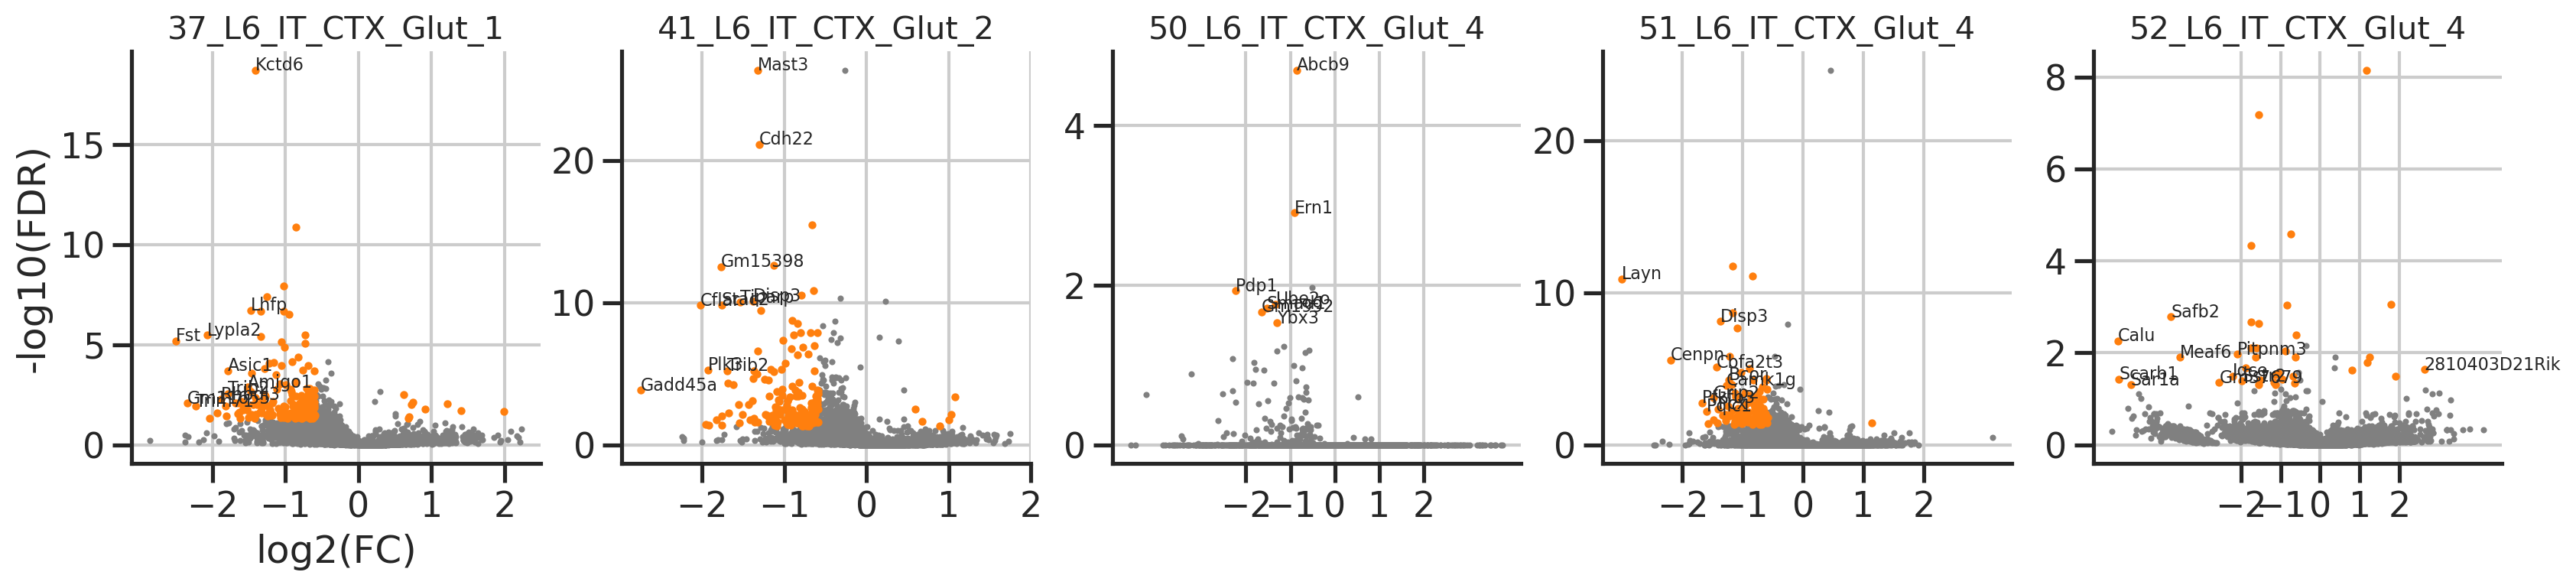

In [10]:
n = len(track_labels)

fig, axs = plt.subplots(1,n,figsize=(4*n,1*3.5)) # , sharey=True)
for i in range(n):
    ax = axs[i]
    df = df_list[i]
    df_sig = df_sig_list[i]
    title = track_labels[i]

    ax.scatter(df['l2fc'].values, df['l10q'].values, s=2, color='gray')
    ax.scatter(df_sig['l2fc'].values, df_sig['l10q'].values, s=5, color='C1')
    for gene, row in df_sig.sort_values('score', ascending=False).head(10).iterrows():
        x = row['l2fc']
        y = row['l10q']
        ax.text(x,y,gene, fontsize=8)
    sns.despine(ax=ax)
    ax.set_title(title, fontsize=15)
    ax.set_xticks([-2,-1,0,1,2])
    
axs[0].set_xlabel('log2(FC)')
axs[0].set_ylabel('-log10(FDR)')
plt.show()

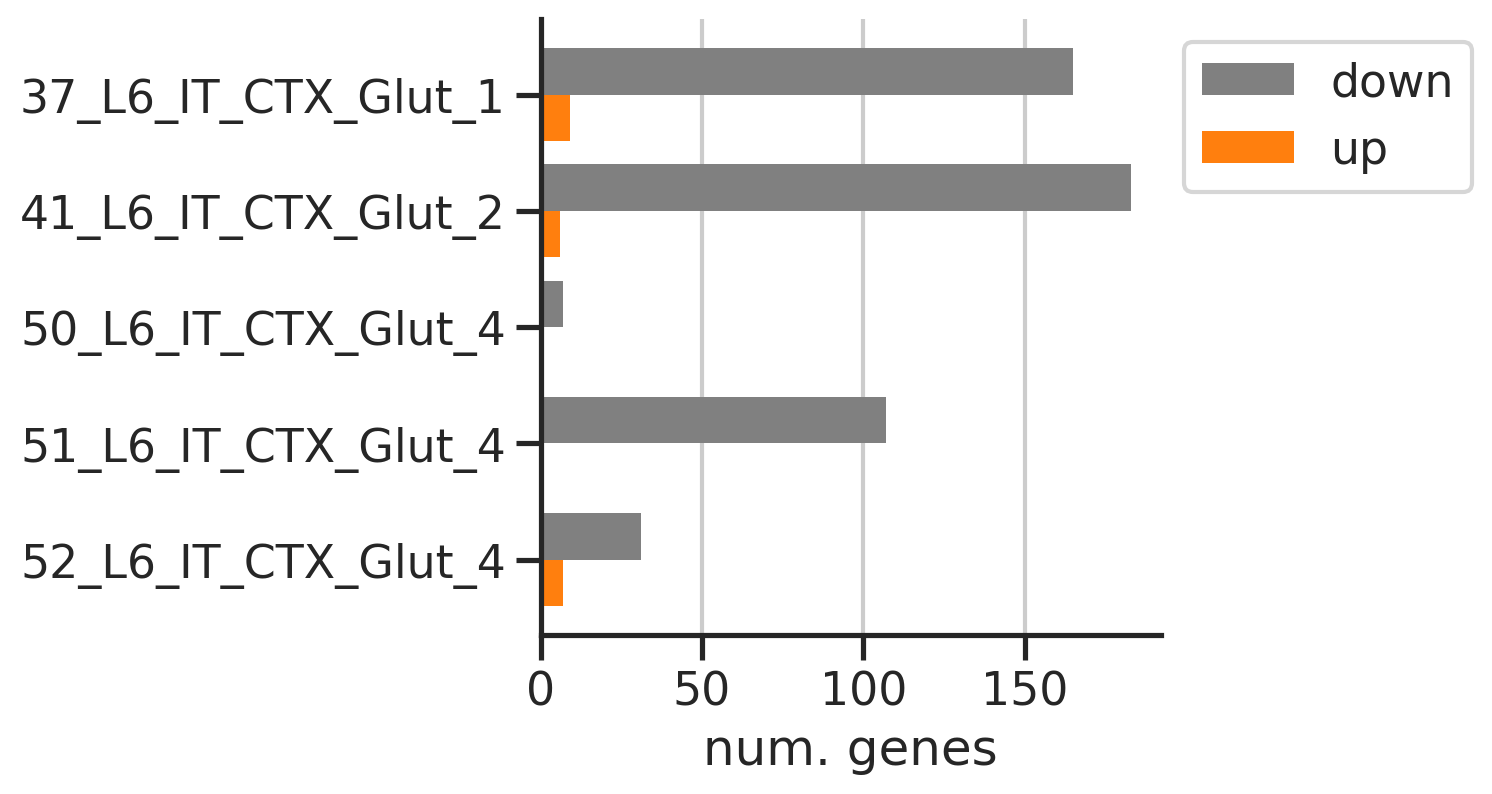

In [11]:

nums_sig = []
for i in range(n):
    df_sig = df_sig_list[i]
    # df_sig.groupby()plot.bar()
    nums_sig.append(df_sig.groupby('direction').size()) # .plot.bar()
    
nums_sig = pd.concat(nums_sig, axis=1).fillna(0) #names=track_labels)
nums_sig.columns = track_labels
fig, ax = plt.subplots(figsize=(4,4))
nums_sig.T.plot.barh(stacked=False, edgecolor='none', width=0.8, color=['gray', 'C1'], ax=ax)
sns.despine(ax=ax)
# ax.set_xticklabels(track_labels)
ax.legend(bbox_to_anchor=(1,1))
ax.invert_yaxis()
ax.grid(axis='y')
ax.set_xlabel('num. genes')
plt.show()


# cell level data

In [12]:
%%time
adata_raw = sc.read(f_raw)
adata_raw

CPU times: user 844 ms, sys: 7.73 s, total: 8.58 s
Wall time: 22.2 s


AnnData object with n_obs × n_vars = 89287 × 16567
    obs: 'Age', 'Doublet', 'Doublet Score', 'n_counts', 'n_genes', 'percent_mito', 'sample', 'Type', 'Subclass', 'Class', 'Sample', 'total_counts', 'pct_counts_mt', 'n_genes_by_counts', 'total_counts_mt', 'Doublet?', 'Study', 'Type_leiden', 'time'
    var: 'feature_types'
    layers: 'norm'

In [13]:
df_lbl = pd.read_csv(f_lbl)
df_lbl['label'] = df_lbl['label'].apply(lambda x: x.replace(' ', '_').replace('/', ''))
df_lbl

,label,conf
AAACCGAAGGAGTCGG-1-P21a-2023 Multiome-9-0,37_L6_IT_CTX_Glut_1,0.347887
AAACGCGCAAACTGTT-1-P21a-2023 Multiome-9-0,51_L6_IT_CTX_Glut_4,1.000000
AAAGCGGGTCTTTGAC-1-P21a-2023 Multiome-9-0,52_L6_IT_CTX_Glut_4,0.677922
AACAGATAGCAAGATG-1-P21a-2023 Multiome-9-0,37_L6_IT_CTX_Glut_1,0.872321
AACAGATAGTTTGAGC-1-P21a-2023 Multiome-9-0,50_L6_IT_CTX_Glut_4,0.606480
...,...,...
TTAGGCTAGCCTAACG-1-P21DRa-2023 Multiome-10-0,50_L6_IT_CTX_Glut_4,0.826069
CTTGTTTAGGAGCAAC-1-P21DRa-2023 Multiome-10-0,37_L6_IT_CTX_Glut_1,0.563911
AAATGCCTCACAGCGC-1-P21DRb-2023 Multiome-10-0,41_L6_IT_CTX_Glut_2,0.536286
GATTATGTCTAAATCG-1-P21DRa-2023 Multiome-10-0,37_L6_IT_CTX_Glut_1,0.807793


In [14]:
adata = adata_raw[df_lbl.index].copy()
adata.obs = adata.obs.join(df_lbl)
adata

AnnData object with n_obs × n_vars = 1718 × 16567
    obs: 'Age', 'Doublet', 'Doublet Score', 'n_counts', 'n_genes', 'percent_mito', 'sample', 'Type', 'Subclass', 'Class', 'Sample', 'total_counts', 'pct_counts_mt', 'n_genes_by_counts', 'total_counts_mt', 'Doublet?', 'Study', 'Type_leiden', 'time', 'label', 'conf'
    var: 'feature_types'
    layers: 'norm'

In [15]:
counts = adata.obs.groupby(['Age', 'label']).size().unstack().T
counts_freq = counts/counts.sum()
counts_freq

Age,P21,P21DR
label,,
37_L6_IT_CTX_Glut_1,0.196944,0.344553
41_L6_IT_CTX_Glut_2,0.319185,0.327724
50_L6_IT_CTX_Glut_4,0.079796,0.054030
51_L6_IT_CTX_Glut_4,0.178268,0.244464
52_L6_IT_CTX_Glut_4,0.225806,0.029229


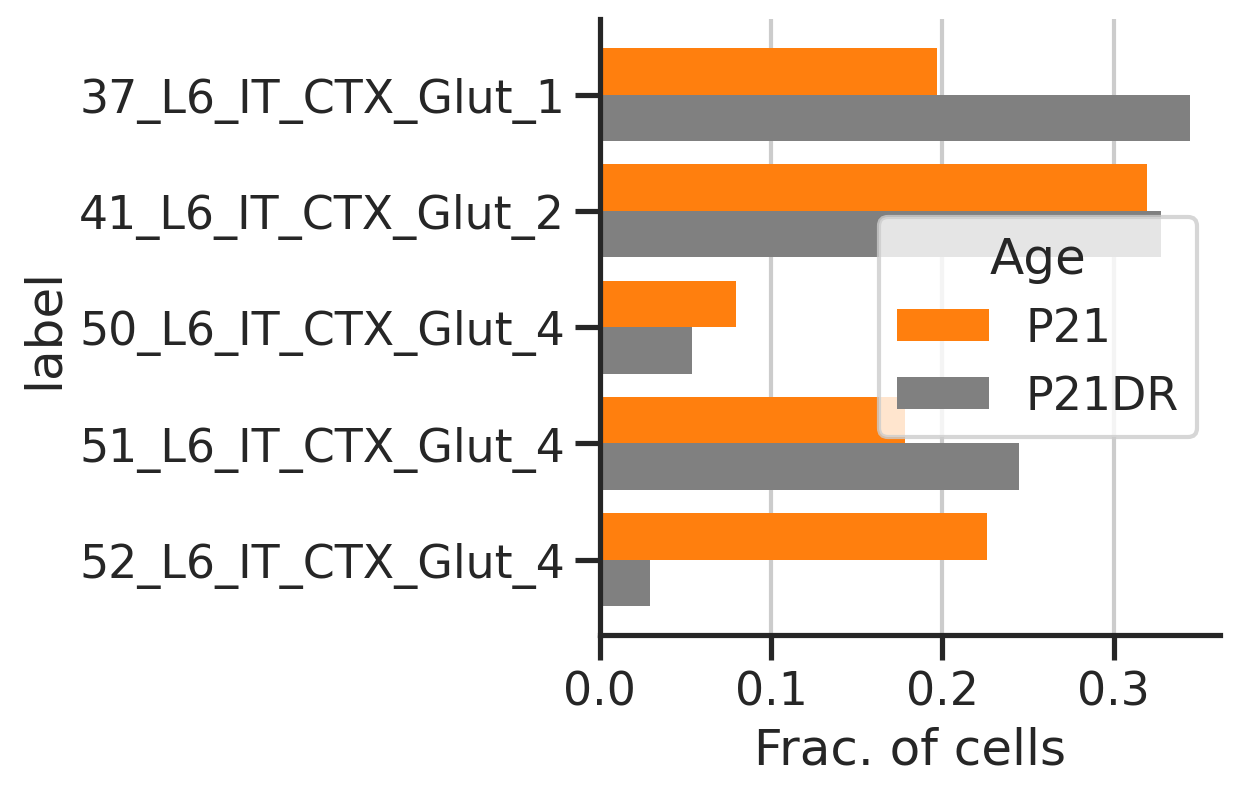

In [16]:

fig, ax = plt.subplots(figsize=(4,4))
counts_freq.plot.barh(width=0.8, edgecolor='none', color=['C1', 'gray'], ax=ax) # , legend=False)
ax.set_xlabel('Frac. of cells')
ax.invert_yaxis()
sns.despine(ax=ax)
ax.grid(axis='y')
plt.show()


<Axes: xlabel='Type', ylabel='label'>

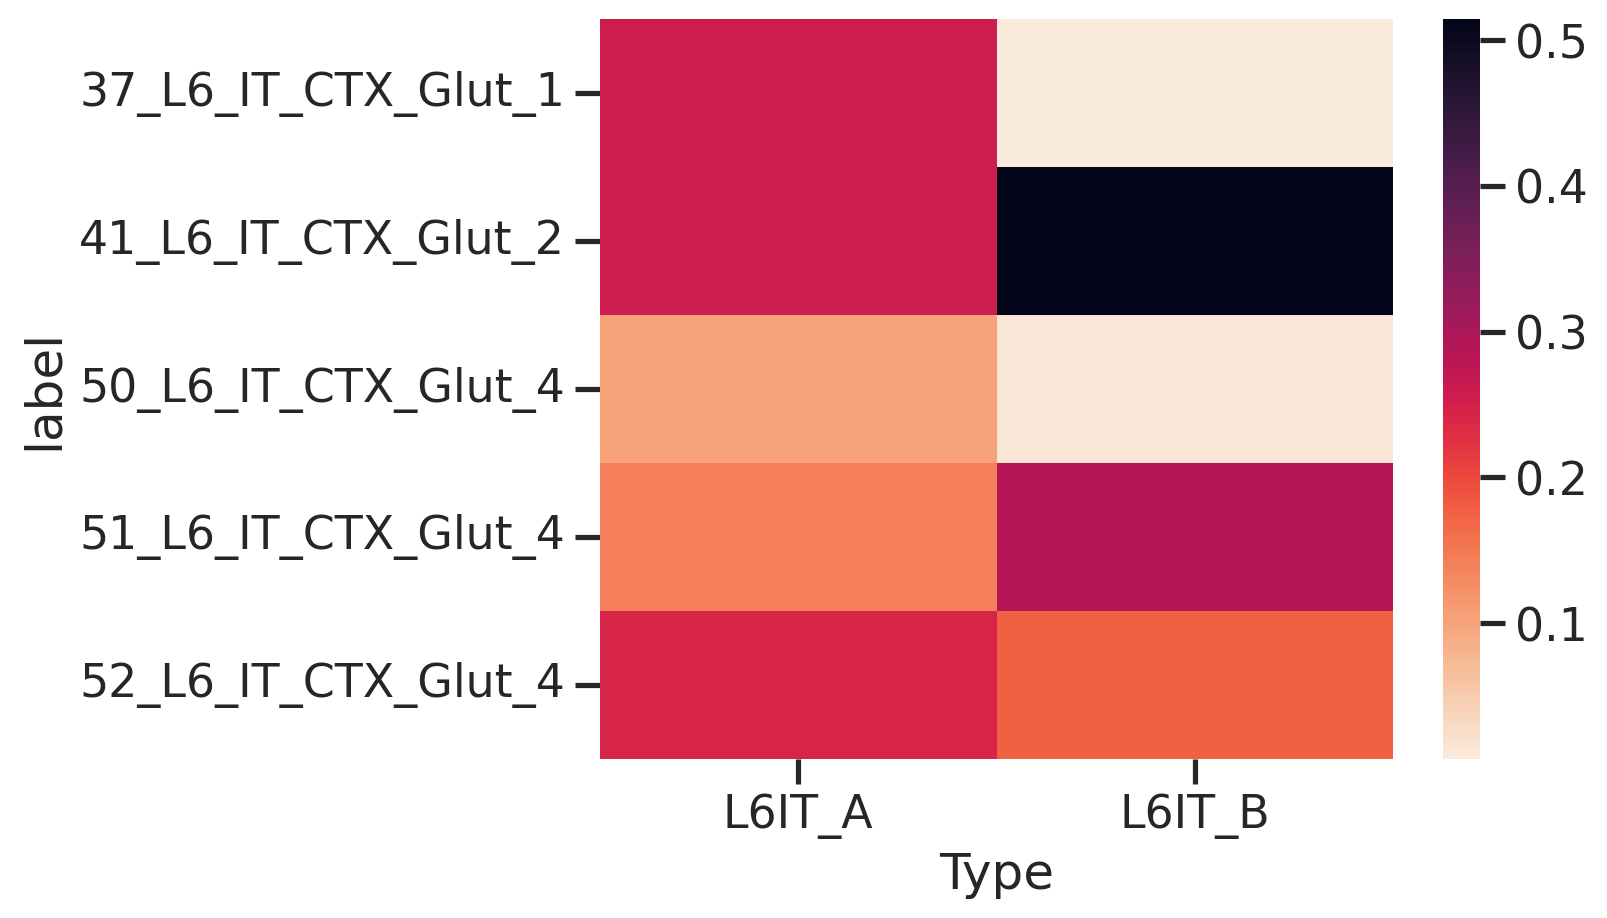

In [17]:
conf = adata[adata.obs['Age']=='P21'].obs.groupby(['label', 'Type']).size().unstack()#.T
conf = conf/conf.sum() 

sns.heatmap(conf, cmap='rocket_r')

<Axes: xlabel='Type', ylabel='label'>

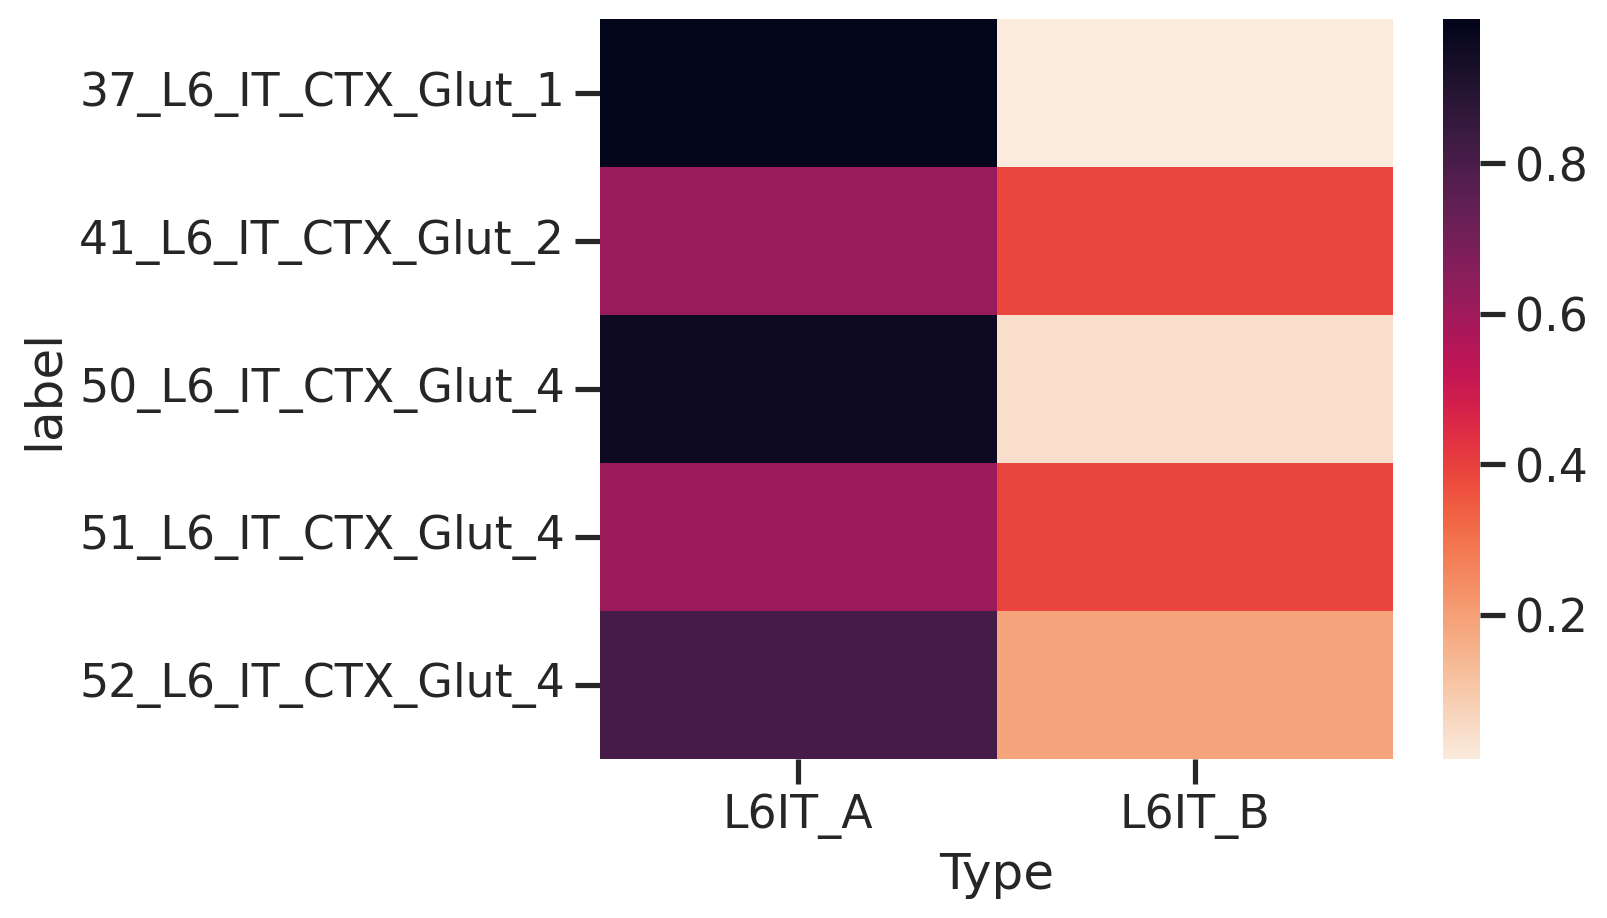

In [18]:
conf = adata[adata.obs['Age']=='P21'].obs.groupby(['label', 'Type']).size().unstack().T
conf = conf/conf.sum() 

sns.heatmap(conf.T, cmap='rocket_r')

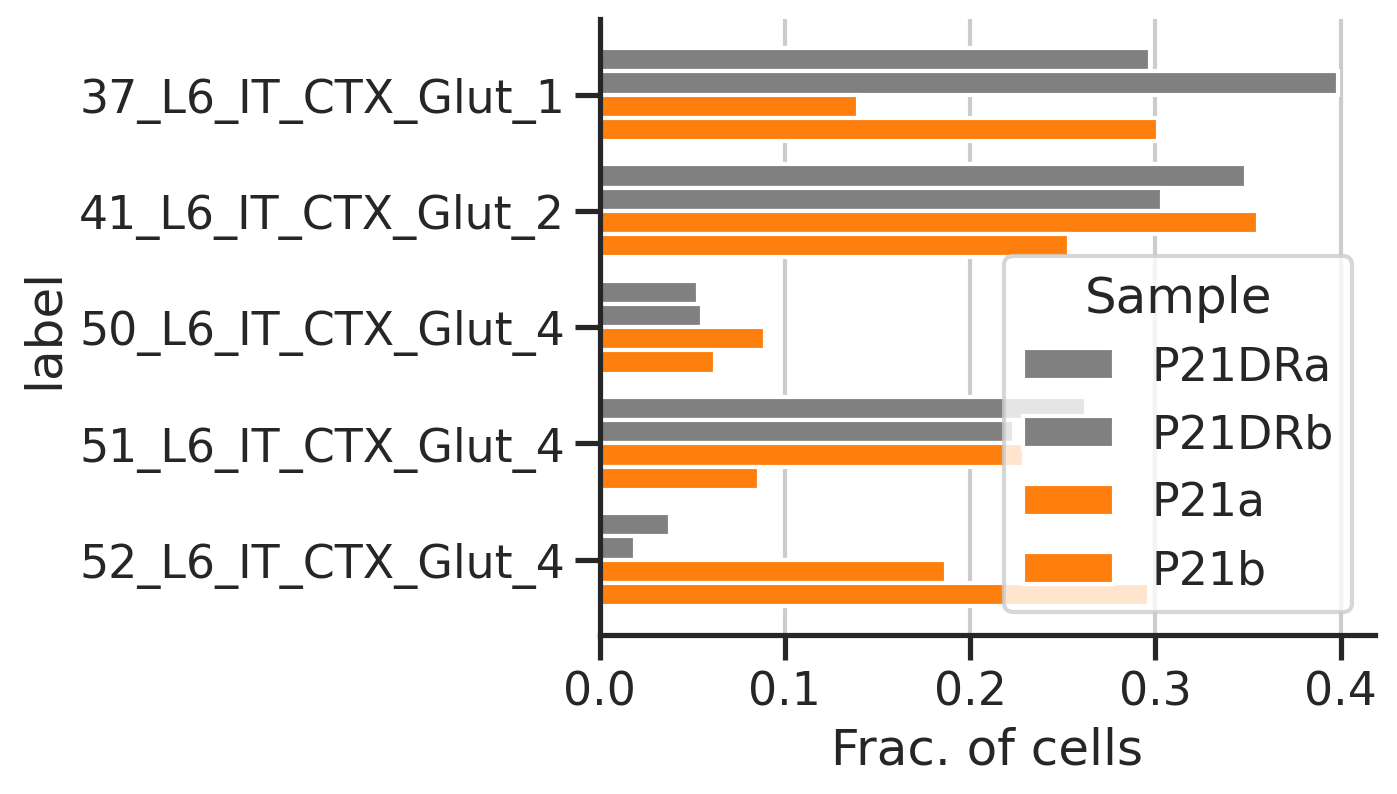

In [19]:
counts = adata.obs.groupby(['Sample', 'label']).size().unstack().T
counts_freq = counts/counts.sum()

fig, ax = plt.subplots(figsize=(5,4))
counts_freq.plot.barh(width=0.8, color=['gray']*2+['C1']*2, ax=ax) # , legend=False)
ax.set_xlabel('Frac. of cells')
ax.invert_yaxis()
sns.despine(ax=ax)
ax.grid(axis='y')
plt.show()

In [20]:
print(adata.obs['Age'].unique())
print(adata.obs['Sample'].unique())
print(adata.obs['label'].unique())

['P21', 'P21DR']
Categories (2, object): ['P21', 'P21DR']
['P21a', 'P21b', 'P21DRb', 'P21DRa']
Categories (4, object): ['P21DRa', 'P21DRb', 'P21a', 'P21b']
['37_L6_IT_CTX_Glut_1' '51_L6_IT_CTX_Glut_4' '52_L6_IT_CTX_Glut_4'
 '50_L6_IT_CTX_Glut_4' '41_L6_IT_CTX_Glut_2']


[INFO] There are 2 conditions. T-Test will be performed...
[INFO] Done!
CPU times: user 284 ms, sys: 8.01 ms, total: 292 ms
Wall time: 290 ms


,baseline_props,mean_props_P21,mean_props_P21DR,prop_ratio,t_statistics,p_values,adjusted_p_values
clusters,,,,,,,
37_L6_IT_CTX_Glut_1,0.293946,0.220455,0.347912,0.633650,-1.584738,0.144109,0.281297
41_L6_IT_CTX_Glut_2,0.324796,0.304426,0.326221,0.933188,-0.252570,0.805716,0.805716
50_L6_IT_CTX_Glut_4,0.062864,0.075837,0.054092,1.401998,0.787863,0.449049,0.561311
51_L6_IT_CTX_Glut_4,0.221769,0.157536,0.243184,0.647806,-1.483430,0.168778,0.281297
52_L6_IT_CTX_Glut_4,0.096624,0.241746,0.028591,8.455434,5.520214,0.000254,0.001272


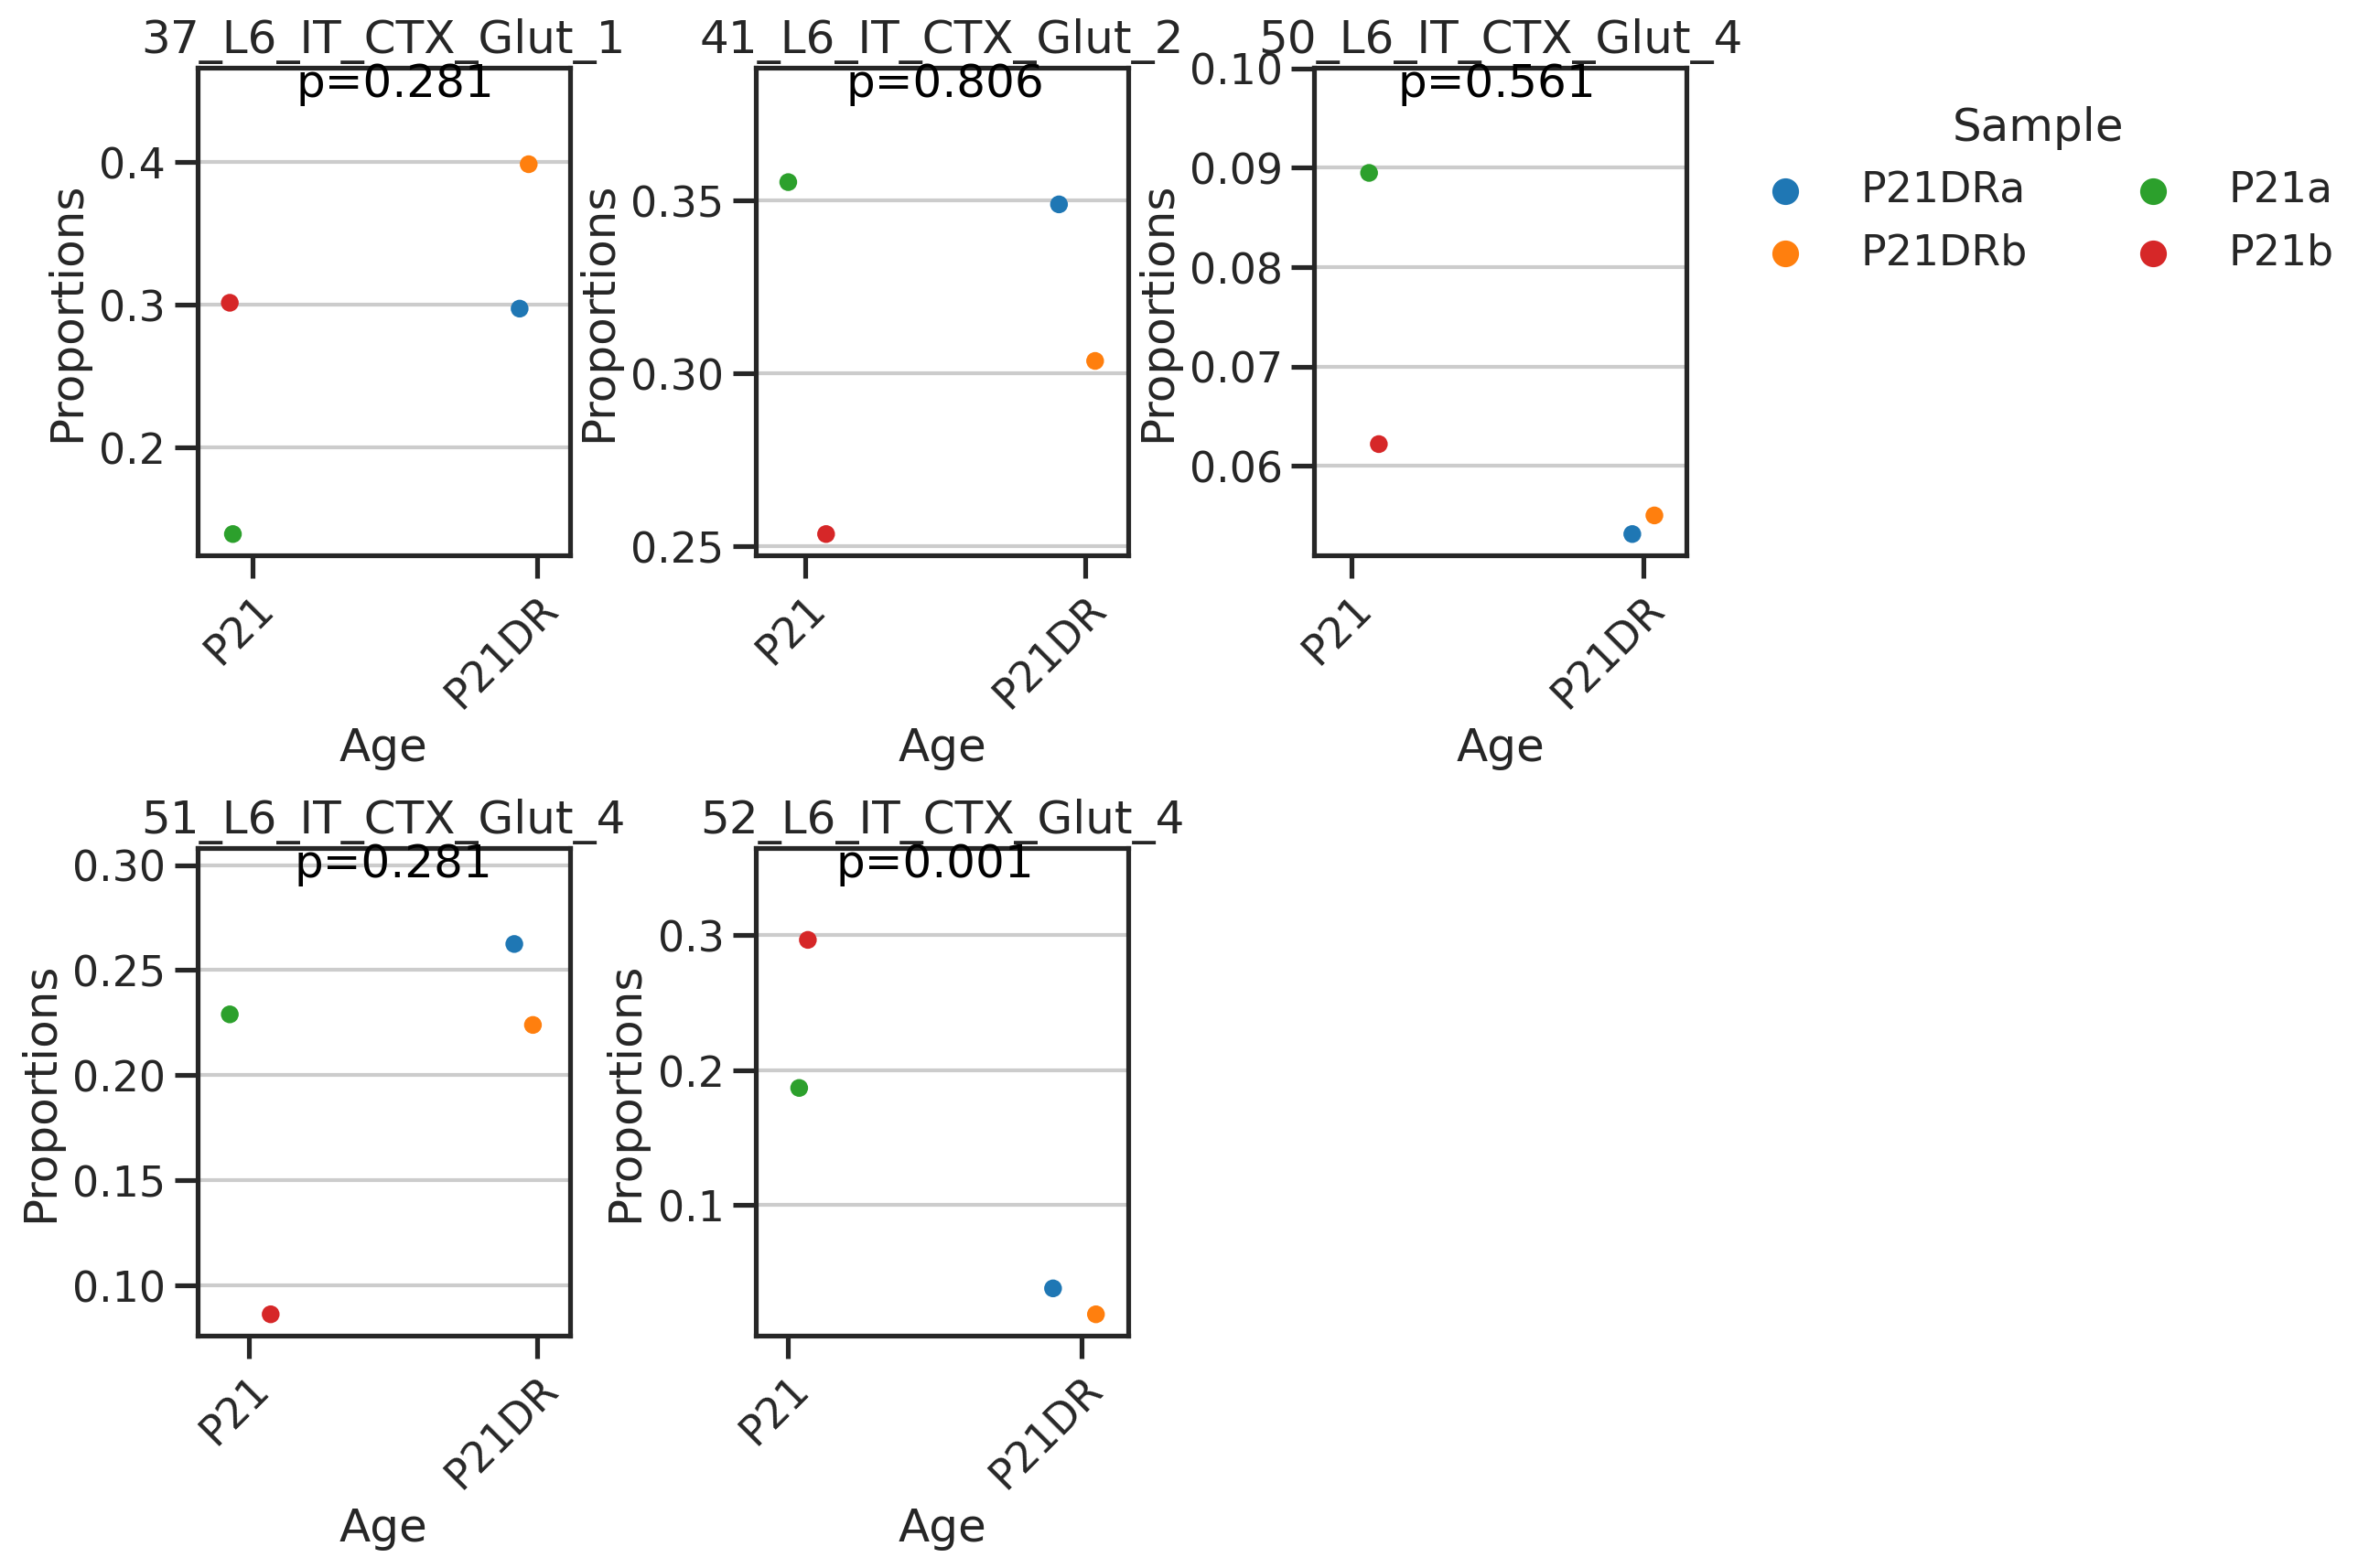

In [25]:
%%time
from scanpro import scanpro

# 2. Run the proportion analysis
# Note: If samples_col=None, Scanpro runs the bootstrapping method for unreplicated data.
out = scanpro(adata, 
              clusters_col='label',   # Column with cell type/cluster labels
              conds_col='Age',      # Column with experimental groups (e.g., Control vs Treated)
              samples_col='Sample',       # Column with replicate/sample IDs
              transform='logit')          # 'logit' or 'arcsin' transformation


# 4. Visualize the shifts
# Generates plots showing proportions across conditions
out.plot(kind='stripplot')  # Options: 'stripplot', 'barplot', or 'boxplot'

out.results

In [22]:
offset = 1e-2
scale = 1e4

mat = np.array(adata.X.todense())/adata.obs['total_counts'].values.reshape(-1,1)*scale
adata.layers['cp10k'] = mat
adata.layers['log2cp10k'] = np.log2(1+mat)
adata

AnnData object with n_obs × n_vars = 1718 × 16567
    obs: 'Age', 'Doublet', 'Doublet Score', 'n_counts', 'n_genes', 'percent_mito', 'sample', 'Type', 'Subclass', 'Class', 'Sample', 'total_counts', 'pct_counts_mt', 'n_genes_by_counts', 'total_counts_mt', 'Doublet?', 'Study', 'Type_leiden', 'time', 'label', 'conf'
    var: 'feature_types'
    layers: 'norm', 'cp10k', 'log2cp10k'

In [19]:
sample_orders = adata.obs['Sample'].astype(str).unique()
print(sample_orders)

palette = {
    'P21': 'C1', 
    'P21DR': 'gray', 
    }

['P21a' 'P21b' 'P21DRb' 'P21DRa']


In [20]:
def plot_one_gene_ax(gene, ax, adata, df_stats):
    """
    """
    dfplot = adata.obs[['Age', 'Sample', 'Subclass']].copy()
    dfplot[gene] = np.array(adata[:,gene].layers['log2cp10k']).reshape(-1,)
    stats = df_stats.loc[gene]

    sns.violinplot(data=dfplot, x='Sample', hue='Age', palette=palette,
                   order=sample_orders, 
                   dodge=False, y=gene, 
                   cut=0, 
                   ax=ax)
    ax.set_title(f'{gene}')

    ax.text(0.05, 0.95, f'q={np.power(10, -stats.l10q):.2g}, l2fc={stats.l2fc:.2g}, conv {stats.converged}', 
            ha='left',
            transform=ax.transAxes, 
            fontsize=12)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=12)
    ax.set_xlabel('')
    ax.set_ylabel('log2(1+cp10k)', fontsize=12)
    sns.despine(ax=ax)
    return dfplot

In [21]:
adata.obs['label'].unique(), track_labels

(array(['37_L6_IT_CTX_Glut_1', '51_L6_IT_CTX_Glut_4',
        '52_L6_IT_CTX_Glut_4', '50_L6_IT_CTX_Glut_4',
        '41_L6_IT_CTX_Glut_2'], dtype=object),
 array(['37_L6_IT_CTX_Glut_1', '41_L6_IT_CTX_Glut_2',
        '50_L6_IT_CTX_Glut_4', '51_L6_IT_CTX_Glut_4',
        '52_L6_IT_CTX_Glut_4'], dtype='<U19'))

In [22]:
adata_list = []
for track_label in track_labels:
    adata_subclass = adata[adata.obs['label']==track_label]
    adata_list.append(adata_subclass)

In [23]:
adata_list

[View of AnnData object with n_obs × n_vars = 505 × 16567
     obs: 'Age', 'Doublet', 'Doublet Score', 'n_counts', 'n_genes', 'percent_mito', 'sample', 'Type', 'Subclass', 'Class', 'Sample', 'total_counts', 'pct_counts_mt', 'n_genes_by_counts', 'total_counts_mt', 'Doublet?', 'Study', 'Type_leiden', 'time', 'label', 'conf'
     var: 'feature_types'
     layers: 'norm', 'cp10k', 'log2cp10k',
 View of AnnData object with n_obs × n_vars = 558 × 16567
     obs: 'Age', 'Doublet', 'Doublet Score', 'n_counts', 'n_genes', 'percent_mito', 'sample', 'Type', 'Subclass', 'Class', 'Sample', 'total_counts', 'pct_counts_mt', 'n_genes_by_counts', 'total_counts_mt', 'Doublet?', 'Study', 'Type_leiden', 'time', 'label', 'conf'
     var: 'feature_types'
     layers: 'norm', 'cp10k', 'log2cp10k',
 View of AnnData object with n_obs × n_vars = 108 × 16567
     obs: 'Age', 'Doublet', 'Doublet Score', 'n_counts', 'n_genes', 'percent_mito', 'sample', 'Type', 'Subclass', 'Class', 'Sample', 'total_counts', 'pct_co

In [24]:
df_raw_list[0]

,log2fc,pval,qval,converged,P21DRa,P21DRb,P21a,P21b,l2fc,l10q
gene,,,,,,,,,,
Xkr4,0.045044,0.853678,0.964185,True,13.022816,12.753589,13.820713,11.354530,0.045044,0.015840
Gm1992,0.320027,0.958167,0.989974,True,0.424534,0.286392,0.400121,0.175902,0.320027,0.004376
Mrpl15,0.423887,0.471805,0.830502,False,0.220036,0.215880,0.156374,0.162681,0.423887,0.080659
Tcea1,0.196111,0.824485,0.959248,False,0.555328,0.546147,0.409733,0.537545,0.196111,0.018069
Rgs20,-0.197204,0.408444,0.803927,True,0.307961,0.354017,0.377624,0.387595,-0.197204,0.094783
...,...,...,...,...,...,...,...,...,...,...
Csf2ra,-0.086518,0.277441,0.706759,False,0.233194,0.206179,0.297056,0.178631,-0.086518,0.150729
Vamp7,0.074154,0.904630,0.975097,True,0.124135,0.097449,0.071953,0.130464,0.074154,0.010952
Tmlhe,-0.076908,0.854188,0.964185,True,0.232961,0.255963,0.174143,0.331054,-0.076908,0.015840


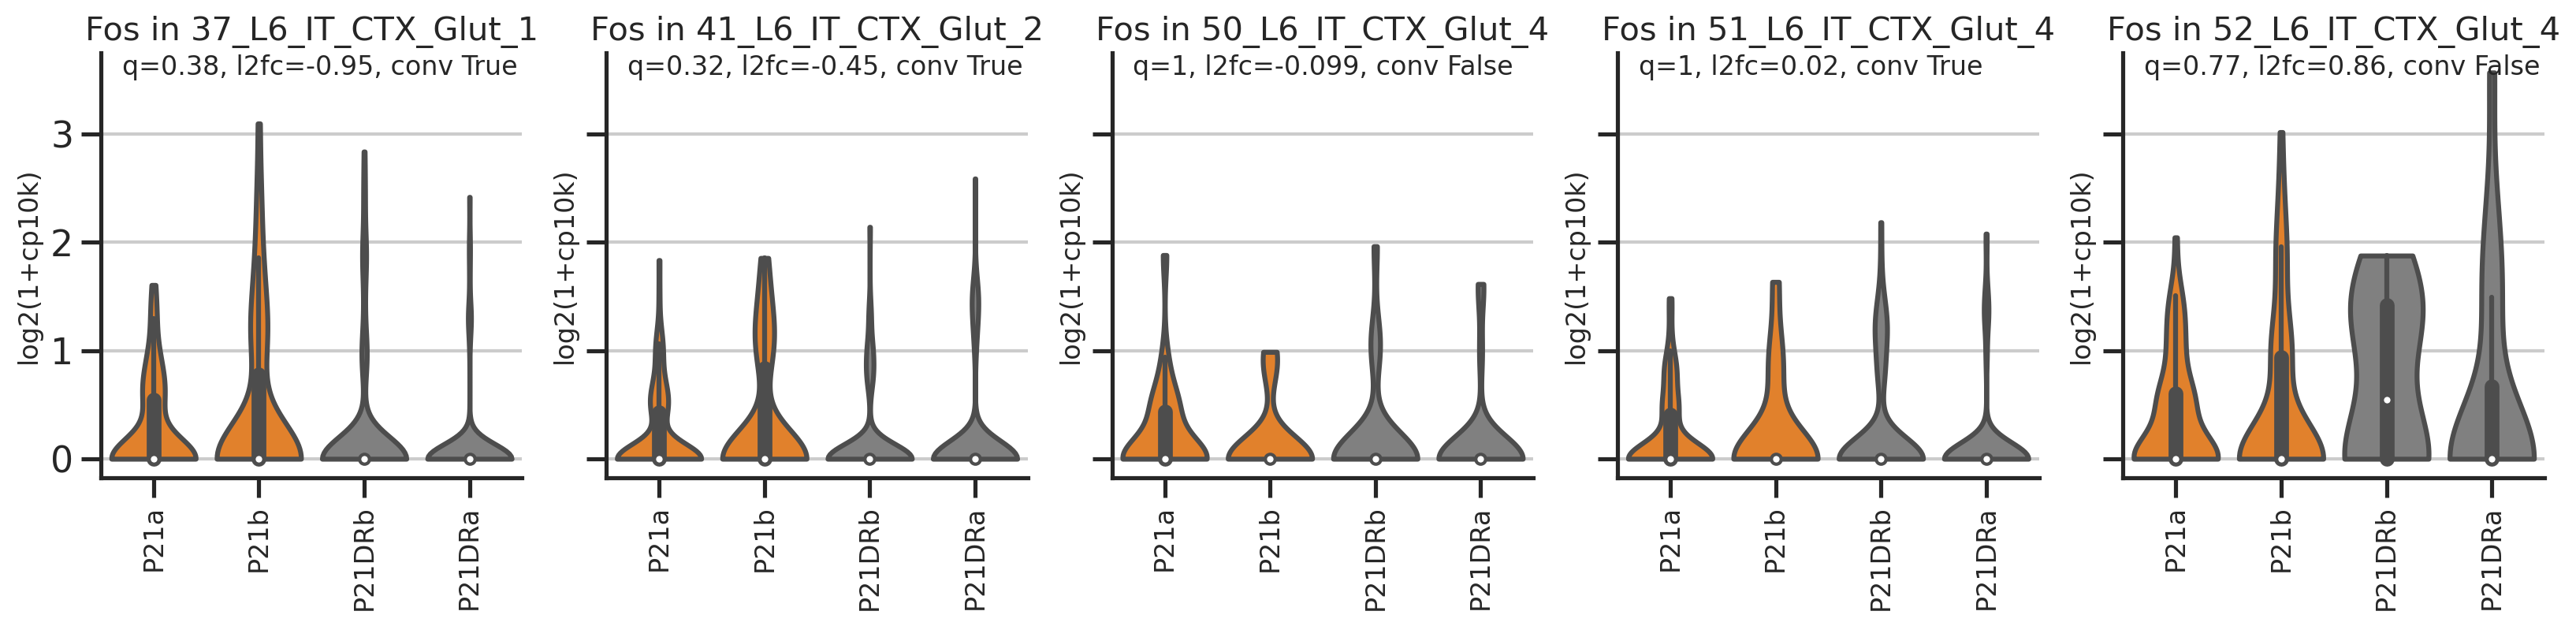

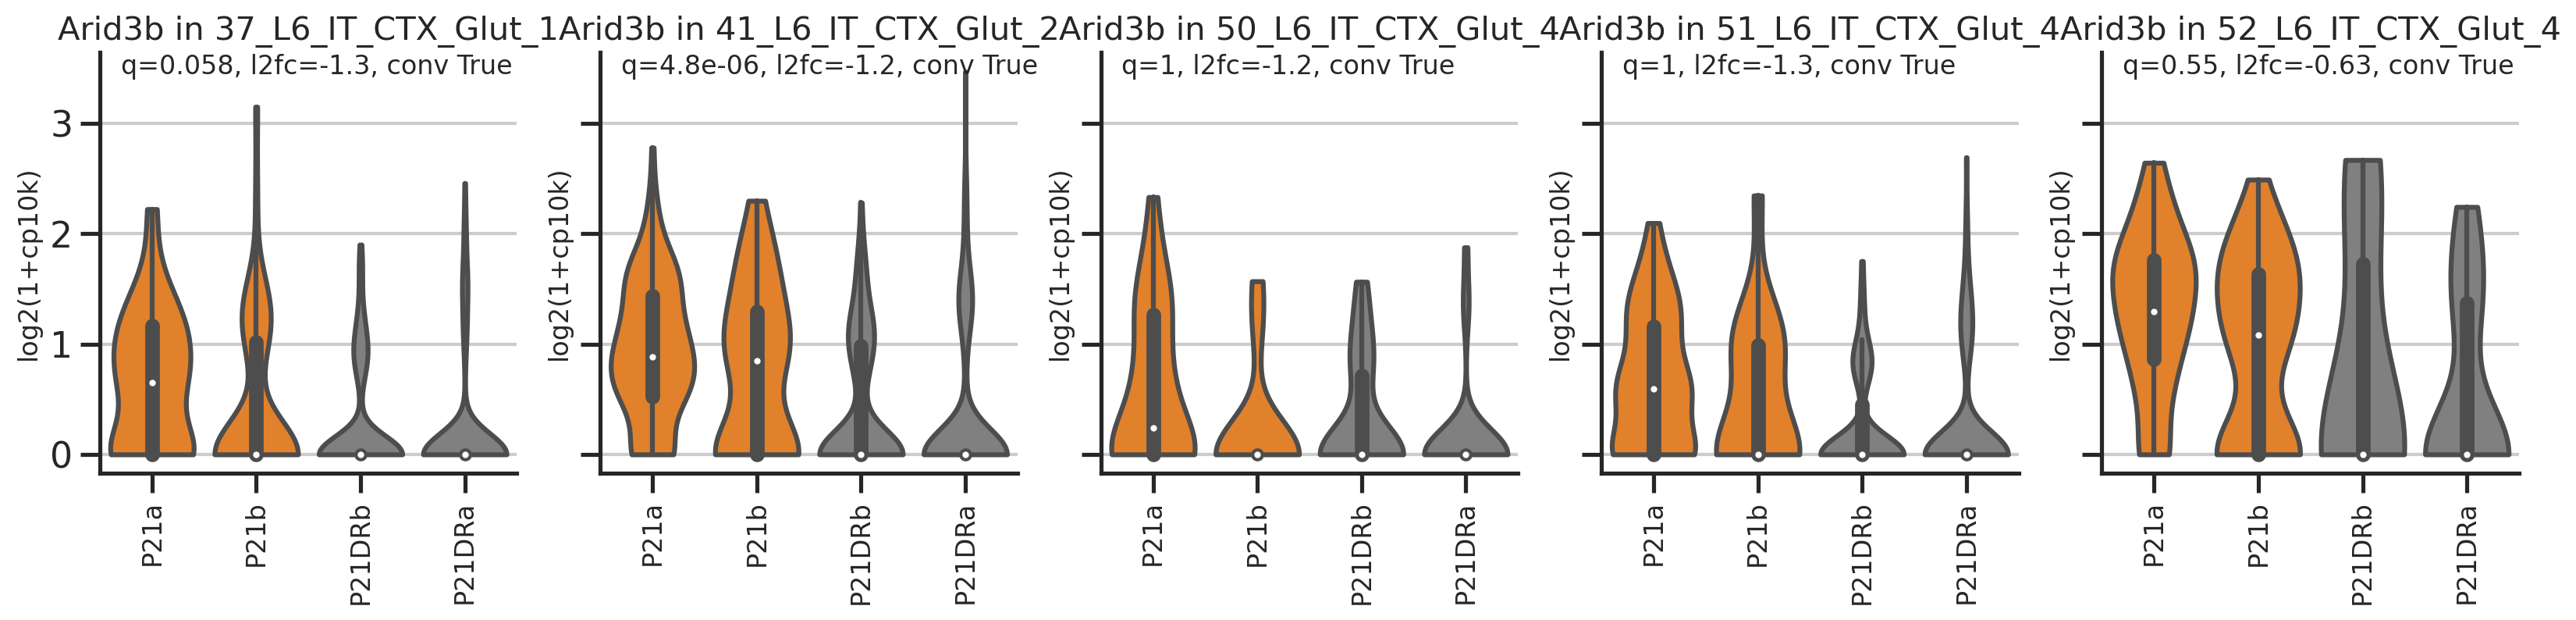

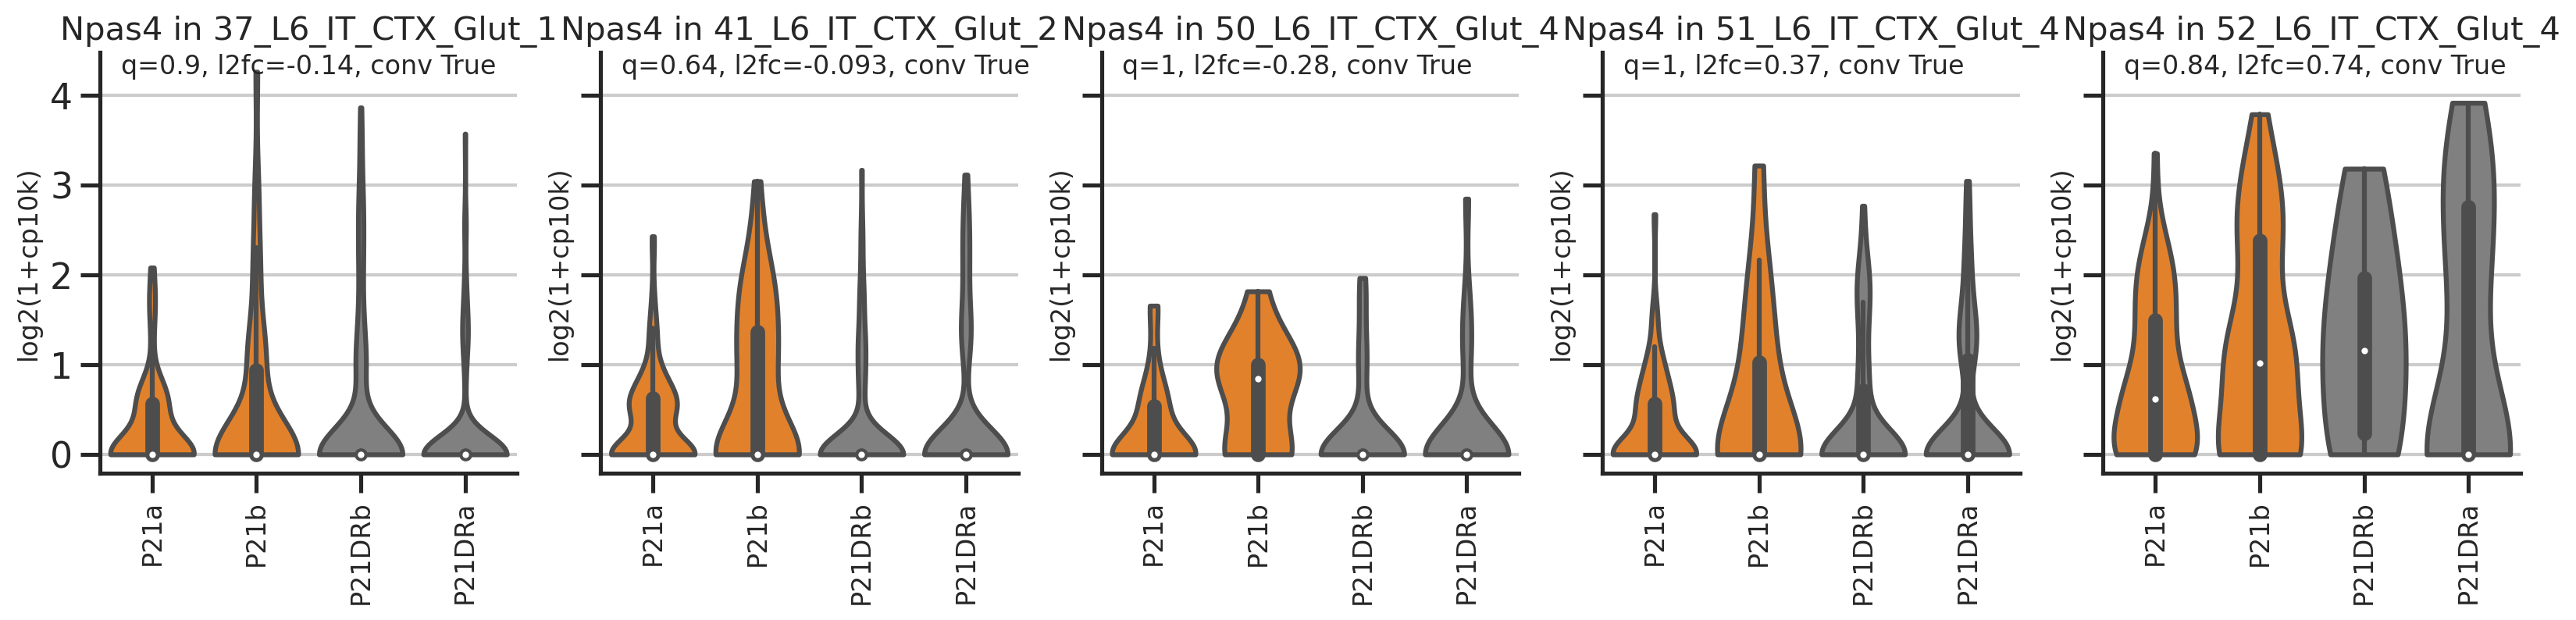

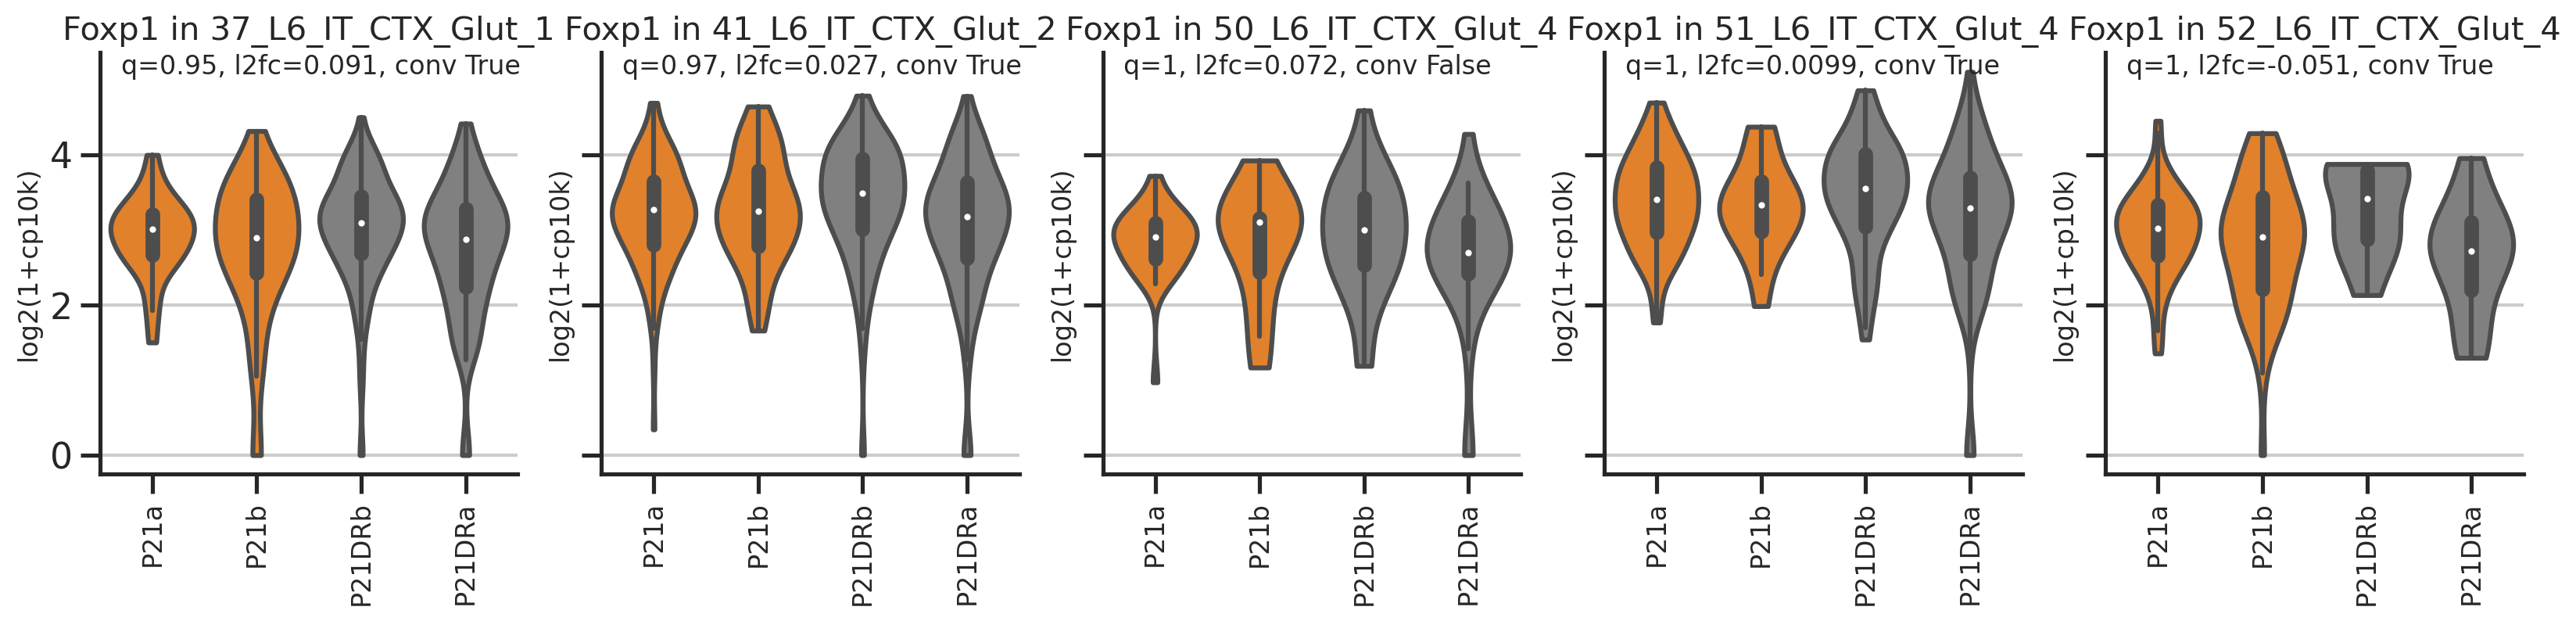

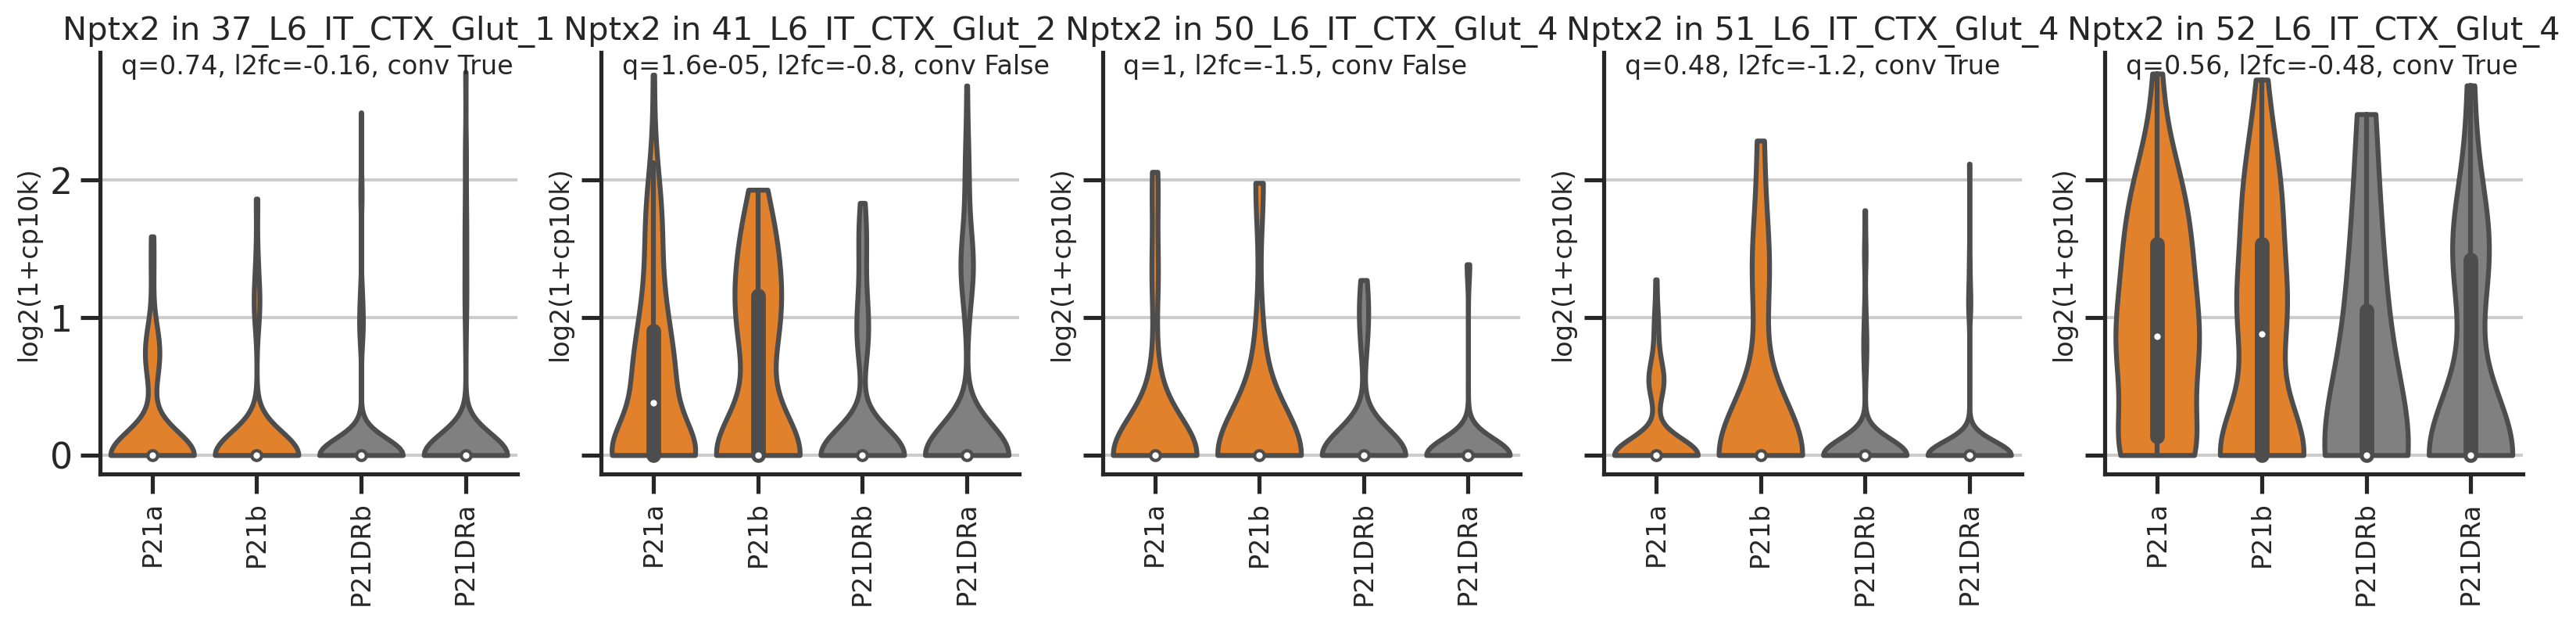

In [25]:
n = len(track_labels)
for gene in ['Fos', 'Arid3b', 'Npas4', 'Foxp1', 'Nptx2']:
    fig, axs = plt.subplots(1, n, figsize=(4*n,3.5), sharey=True, sharex=True)
    for i in range(n):
        ax = axs[i]
        df = df_raw_list[i]
        adata_subclass = adata_list[i]
        track_label = track_labels[i]
        
        dfplot = plot_one_gene_ax(gene, ax, adata_subclass, df)
        ax.set_title(f'{gene} in {track_label}', fontsize=15)
        ax.legend_.remove()

    plt.show()

# shared vs different